# Attention / activation viz

Uses `interp.py`. Pick the `.venv` kernel (top-right) before running.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import interp

m = interp.load("gpt2-small")
cap = interp.run(m, "The cat sat on the")
print(cap.tokens)

/Users/nshelton/c3p0/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 8012.15it/s]

Loaded pretrained model gpt2-small into HookedTransformer
['<|endoftext|>', 'The', ' cat', ' sat', ' on', ' the']


## Shapes

`cap.attn` is `[n_layers, n_heads, seq, seq]`. For gpt2-small that's `12 layers x 12 heads`. `cap.attn[layer, head]` is one head's `[query, key]` matrix.

In [2]:
print("n_layers:", m.cfg.n_layers)
print("n_heads: ", m.cfg.n_heads)
print("attn:    ", cap.attn.shape, "[layer, head, query, key]")
print("logits:  ", cap.logits.shape, "[seq, vocab]")

n_layers: 12
n_heads:  12
attn:     (12, 12, 6, 6) [layer, head, query, key]
logits:   (6, 50257) [seq, vocab]


## Predict the next token

`cap.logits[-1]` is the distribution over the vocab for the position *after* the last token. `interp.predict` softmaxes it and returns the top-k.

 8.66%  ' floor'
 6.29%  ' bed'
 5.16%  ' couch'
 4.25%  ' ground'
 4.15%  ' edge'
 3.07%  ' sofa'
 2.82%  ' back'
 2.44%  ' bench'
 2.43%  ' table'
 1.98%  ' side'


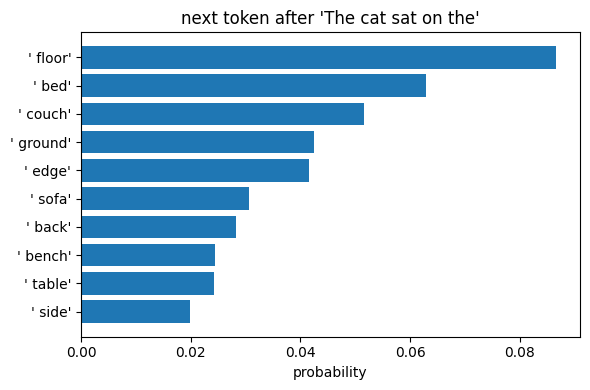

In [3]:
top = interp.predict(m, cap, k=10)
for tok, p in top:
    print(f"{p:6.2%}  {tok!r}")

toks = [t for t, _ in top][::-1]
ps = [p for _, p in top][::-1]
plt.figure(figsize=(6, 4))
plt.barh(range(len(toks)), ps)
plt.yticks(range(len(toks)), [repr(t) for t in toks])
plt.xlabel("probability")
plt.title(f"next token after {cap.prompt!r}")
plt.tight_layout()
plt.show()

## One head's attention

Row = query (attending from), column = key (attended to). Causal, so it's lower-triangular.

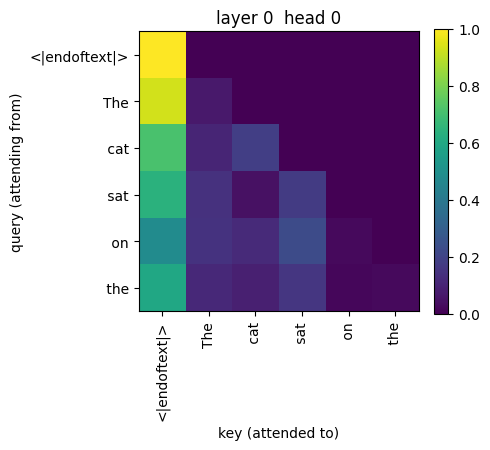

In [4]:
layer, head = 0, 0
A = cap.attn[layer, head]

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(A, cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(len(cap.tokens)))
ax.set_xticklabels(cap.tokens, rotation=90)
ax.set_yticks(range(len(cap.tokens)))
ax.set_yticklabels(cap.tokens)
ax.set_xlabel("key (attended to)")
ax.set_ylabel("query (attending from)")
ax.set_title(f"layer {layer}  head {head}")
fig.colorbar(im, fraction=0.046)
plt.tight_layout()
plt.show()

## Every head in a layer

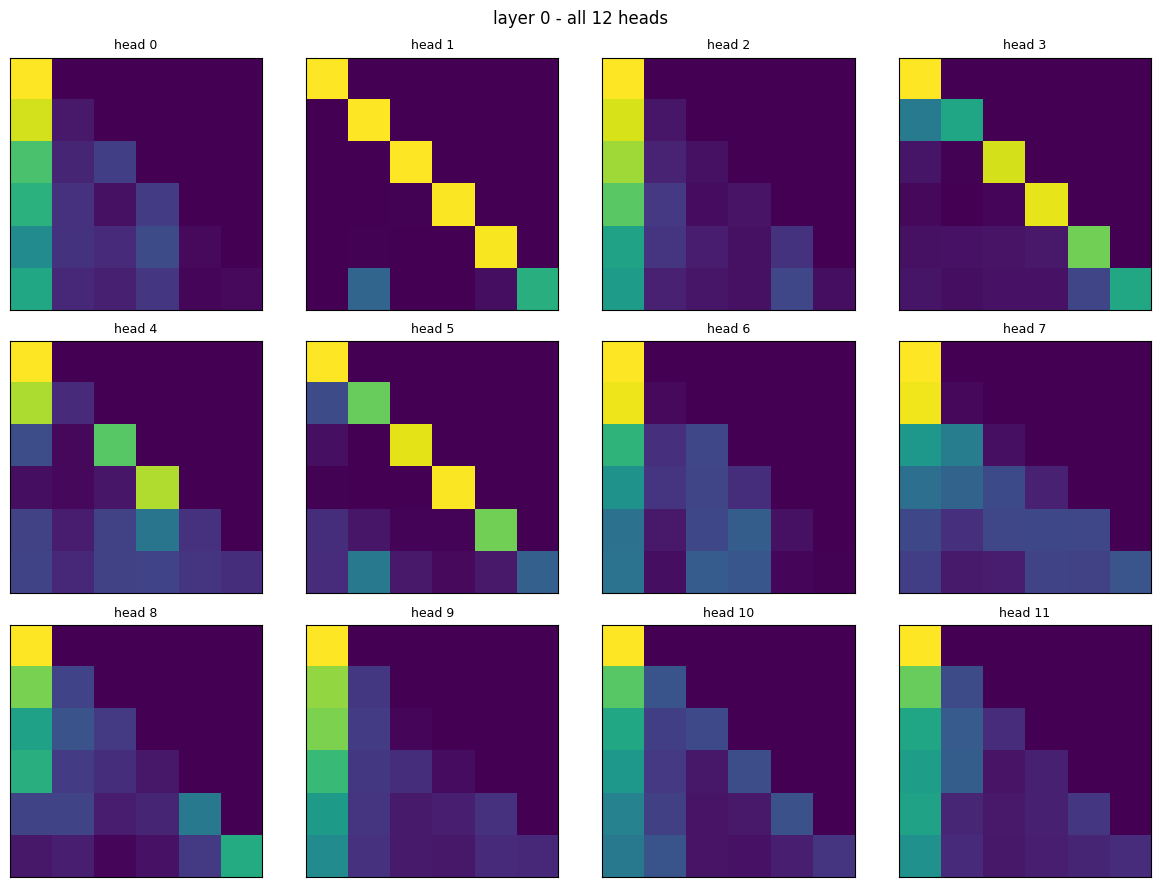

In [5]:
layer = 0
nh = m.cfg.n_heads
cols = 4
rows = (nh + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
for h, ax in enumerate(axes.flat):
    if h < nh:
        ax.imshow(cap.attn[layer, h], cmap="viridis", vmin=0, vmax=1)
        ax.set_title(f"head {h}", fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle(f"layer {layer} - all {nh} heads")
plt.tight_layout()
plt.show()

## Activations

Any named activation via `interp.act(cap, name, layer)`. Here the residual stream after layer 6, `[seq, d_model]`.

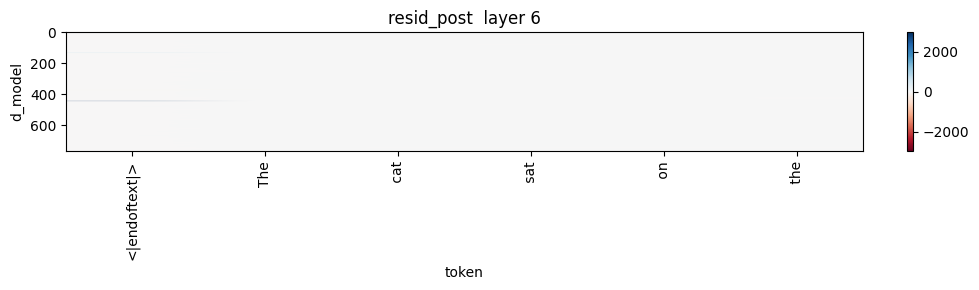

In [6]:
r = interp.act(cap, "resid_post", 6)  # [seq, d_model]
lim = np.abs(r).max()

plt.figure(figsize=(10, 3))
plt.imshow(r.T, aspect="auto", cmap="RdBu", vmin=-lim, vmax=lim)
plt.xticks(range(len(cap.tokens)), cap.tokens, rotation=90)
plt.xlabel("token")
plt.ylabel("d_model")
plt.title("resid_post  layer 6")
plt.colorbar(fraction=0.046)
plt.tight_layout()
plt.show()

### Tip: list every activation name in the cache

`cap.cache` is the raw TransformerLens `ActivationCache`. Keys you can pass to `interp.act`:

In [7]:
for k in list(cap.cache.keys())[:30]:
    print(k, tuple(cap.cache[k].shape))

hook_embed (1, 6, 768)
hook_pos_embed (1, 6, 768)
blocks.0.hook_resid_pre (1, 6, 768)
blocks.0.ln1.hook_scale (1, 6, 1)
blocks.0.ln1.hook_normalized (1, 6, 768)
blocks.0.attn.hook_q (1, 6, 12, 64)
blocks.0.attn.hook_k (1, 6, 12, 64)
blocks.0.attn.hook_v (1, 6, 12, 64)
blocks.0.attn.hook_attn_scores (1, 12, 6, 6)
blocks.0.attn.hook_pattern (1, 12, 6, 6)
blocks.0.attn.hook_z (1, 6, 12, 64)
blocks.0.hook_attn_out (1, 6, 768)
blocks.0.hook_resid_mid (1, 6, 768)
blocks.0.ln2.hook_scale (1, 6, 1)
blocks.0.ln2.hook_normalized (1, 6, 768)
blocks.0.mlp.hook_pre (1, 6, 3072)
blocks.0.mlp.hook_post (1, 6, 3072)
blocks.0.hook_mlp_out (1, 6, 768)
blocks.0.hook_resid_post (1, 6, 768)
blocks.1.hook_resid_pre (1, 6, 768)
blocks.1.ln1.hook_scale (1, 6, 1)
blocks.1.ln1.hook_normalized (1, 6, 768)
blocks.1.attn.hook_q (1, 6, 12, 64)
blocks.1.attn.hook_k (1, 6, 12, 64)
blocks.1.attn.hook_v (1, 6, 12, 64)
blocks.1.attn.hook_attn_scores (1, 12, 6, 6)
blocks.1.attn.hook_pattern (1, 12, 6, 6)
blocks.1.attn.ho